<a href="https://colab.research.google.com/github/slimisgit/grokking/blob/new_model/report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

статья: [url text](https://www.lesswrong.com/posts/bTgTggoKRGLRF4enD/grokking-revisited-reverse-engineering-grokking-modulo)

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt #графики
import numpy as np
import os

#создание дата сета
def create_dataset(N, fraction_train, seed=42):
    np.random.seed(seed)
    all_pairs = [(x, y) for x in range(N) for y in range(N)]
    np.random.shuffle(all_pairs)
    all_pairs = np.array(all_pairs)

    total_size = len(all_pairs)
    train_size = int(total_size * fraction_train)
    test_size = total_size - train_size

    train_pairs = all_pairs[:train_size]
    test_pairs = all_pairs[train_size:]

    def pairs_to_dataset(pairs):
        xs = torch.tensor(pairs[:, 0], dtype=torch.long)
        ys = torch.tensor(pairs[:, 1], dtype=torch.long)
        targets = (xs + ys) % N
        return xs, ys, targets

    train_x, train_y, train_t = pairs_to_dataset(train_pairs)
    test_x, test_y, test_t = pairs_to_dataset(test_pairs)
    train_seq = torch.stack([train_x, train_y], dim=1)
    train_targets = train_t
    test_seq = torch.stack([test_x, test_y], dim=1)
    test_targets = test_t

    return train_seq, train_targets, test_seq, test_targets


#модель
class LSTMModelOneHot(nn.Module):
    def __init__(self, vocab_size, hidden_size=128):
        super(LSTMModelOneHot, self).__init__()
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size


        self.W_ih = nn.Linear(vocab_size, 4*hidden_size, bias=True)  #это типо 4 матрицы в одной для скорости
        self.W_hh = nn.Linear(hidden_size, 4*hidden_size, bias=True)
        self.fc1 = nn.Linear(hidden_size,  vocab_size, bias=False)

        self.relu = nn.ReLU()

    #один шаг по времени(вообще по времени в батче,но у нас батч=эпоха)
    def forward(self, x_seq):

        batch_size, seq_len = x_seq.size()
        device = x_seq.device

        #представление батча в onehot
        x_onehot = torch.zeros(batch_size, seq_len, self.vocab_size, device=device)
        x_onehot.scatter_(2, x_seq.unsqueeze(2), 1)

        #начальные долгосрочная и короткосрочная память
        h = torch.zeros(batch_size, self.hidden_size, device=device)
        c = torch.zeros(batch_size, self.hidden_size, device=device)


        for t in range(seq_len):
            #типо времени в LSTM (тут или 0 или 1)
            x_t = x_onehot[:, t, :]

            #логика LSTM,но т.к матрицы склеены в одну читать невозможно
            gates = self.W_ih(x_t) + self.W_hh(h)
            i = torch.sigmoid(gates[:, 0:self.hidden_size])  # input gate
            f = torch.sigmoid(gates[:, self.hidden_size:2*self.hidden_size])  # forget gate
            g = torch.tanh(gates[:, 2*self.hidden_size:3*self.hidden_size]) # candidate gate
            o = torch.sigmoid(gates[:, 3*self.hidden_size:4*self.hidden_size]) # output gate

            #логика долгосрочной памяти
            c = f * c + i * g

            h = torch.tanh(c)*o #

        logits = self.fc1(h)

        return logits

In [8]:
# функция обучения
def train_and_test_with_params(seed: int, N=113,
                               fraction_train=0.3,
                               lr=1e-3,
                               weight_decay=1.0,
                               betas=(0.9, 0.98),
                               epochs=100000,
                               checkpoint_interval=200):
    # установка сида рандома + рандом
    torch.manual_seed(seed)
    np.random.seed(seed)
    train_seq, train_targets, test_seq, test_targets = create_dataset(N, fraction_train, seed)

    # сама модель
    hidden_size = N
    model = LSTMModelOneHot(N, hidden_size=hidden_size)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay, betas=betas)
    criterion = nn.CrossEntropyLoss()  # функция loss
    os.makedirs("checkpoints_lstm_report", exist_ok=True)

    # подсчет точности модели
    def evaluate(model, x_seq, targets, batch_size=512):
        model.eval()  # не обучаемся
        correct = 0
        total = 0
        with torch.no_grad():  # не обучаемся
            for start in range(0, len(x_seq), batch_size):
                end = start + batch_size
                batch_seq = x_seq[start:end].to(next(model.parameters()).device)
                batch_t = targets[start:end].to(next(model.parameters()).device)
                logits = model(batch_seq)
                preds = torch.argmax(logits, dim=1)
                correct += (preds == batch_t).sum().item()
                total += (end - start)
        return correct / total

    # подсчет функции потерь с усреднением по батчу
    def full_loss(model, x_seq, targets, batch_size=512):
        model.eval()
        total_loss = 0.0
        count = 0
        with torch.no_grad():
            for start in range(0, len(x_seq), batch_size):
                end = start + batch_size
                batch_seq = x_seq[start:end].to(next(model.parameters()).device)
                batch_t = targets[start:end].to(next(model.parameters()).device)
                logits = model(batch_seq)
                loss = criterion(logits, batch_t)
                total_loss += loss.item() * (end - start)
                count += (end - start)
        return total_loss / count

    # обучение модели
    # перенос всего на ускоритель,если возможно
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    train_seq = train_seq.to(device)
    train_targets = train_targets.to(device)
    test_seq = test_seq.to(device)
    test_targets = test_targets.to(device)

    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()  # градиенты иначе будут складываться между эпохами(т.к они вроде локально сопоставлены торчам)
        logits = model(train_seq)
        loss = criterion(logits, train_targets)
        loss.backward()
        optimizer.step()

        # данные для логов
        if (epoch % checkpoint_interval == 0) or (epoch == epochs - 1):
            train_loss = full_loss(model, train_seq, train_targets)
            test_loss = full_loss(model, test_seq, test_targets)
            train_acc = evaluate(model, train_seq, train_targets)
            test_acc = evaluate(model, test_seq, test_targets)

            train_losses.append((epoch, train_loss))
            test_losses.append((epoch, test_loss))
            train_accuracies.append((epoch, train_acc))
            test_accuracies.append((epoch, test_acc))

            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}, "
                  f"Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}")

            checkpoint_path = f"checkpoints_lstm_report/model_epoch_{epoch}.pt"
            torch.save(model.state_dict(), checkpoint_path)

    return train_losses, train_accuracies, test_losses, test_accuracies


#отрисовка графиков
def graphic(train_losses, train_accuracies, test_losses, test_accuracies):
    epochs_logged = [e for e, _ in train_losses]
    train_loss_vals = [l for _, l in train_losses]
    test_loss_vals = [l for _, l in test_losses]
    train_acc_vals = [a for _, a in train_accuracies]
    test_acc_vals = [a for _, a in test_accuracies]

    plt.figure(figsize=(14, 10))

    # верхний левый — Loss (обычный)
    plt.subplot(2, 2, 1)
    plt.plot(epochs_logged, train_loss_vals, label='Train Loss')
    plt.plot(epochs_logged, test_loss_vals, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Time')
    plt.legend()

    # верхний правый — Accuracy (обычный)
    plt.subplot(2, 2, 2)
    plt.plot(epochs_logged, train_acc_vals, label='Train Acc')
    plt.plot(epochs_logged, test_acc_vals, label='Test Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Time')
    plt.legend()

    # нижний левый — Loss (log-log)
    plt.subplot(2, 2, 3)
    plt.loglog(epochs_logged, train_loss_vals, label='Train Loss')
    plt.loglog(epochs_logged, test_loss_vals, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Time (Log-Log)')
    plt.legend()

    # нижний правый — Accuracy (log-log)
    plt.subplot(2, 2, 4)
    plt.loglog(epochs_logged, train_acc_vals, label='Train Acc')
    plt.loglog(epochs_logged, test_acc_vals, label='Test Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Time (Log-Log)')
    plt.legend()

    plt.tight_layout()
    plt.show()


Epoch 0: Train Loss=4.7268, Test Loss=4.7280, Train Acc=0.0076, Test Acc=0.0094
Epoch 200: Train Loss=3.8093, Test Loss=5.6977, Train Acc=0.1111, Test Acc=0.0002
Epoch 400: Train Loss=2.7678, Test Loss=7.3892, Train Acc=0.2563, Test Acc=0.0000
Epoch 600: Train Loss=1.8459, Test Loss=8.8839, Train Acc=0.6611, Test Acc=0.0000
Epoch 800: Train Loss=1.1379, Test Loss=9.9899, Train Acc=0.8967, Test Acc=0.0000
Epoch 1000: Train Loss=0.6759, Test Loss=10.8153, Train Acc=0.9343, Test Acc=0.0000
Epoch 1200: Train Loss=0.3955, Test Loss=11.3939, Train Acc=0.9351, Test Acc=0.0000
Epoch 1400: Train Loss=0.2315, Test Loss=11.7602, Train Acc=0.9351, Test Acc=0.0000
Epoch 1600: Train Loss=0.1368, Test Loss=11.9464, Train Acc=0.9351, Test Acc=0.0000
Epoch 1800: Train Loss=0.0813, Test Loss=11.9672, Train Acc=0.9351, Test Acc=0.0001
Epoch 2000: Train Loss=0.0485, Test Loss=11.8095, Train Acc=0.9351, Test Acc=0.0002
Epoch 2200: Train Loss=0.0290, Test Loss=11.5453, Train Acc=0.9351, Test Acc=0.0004
Epoc

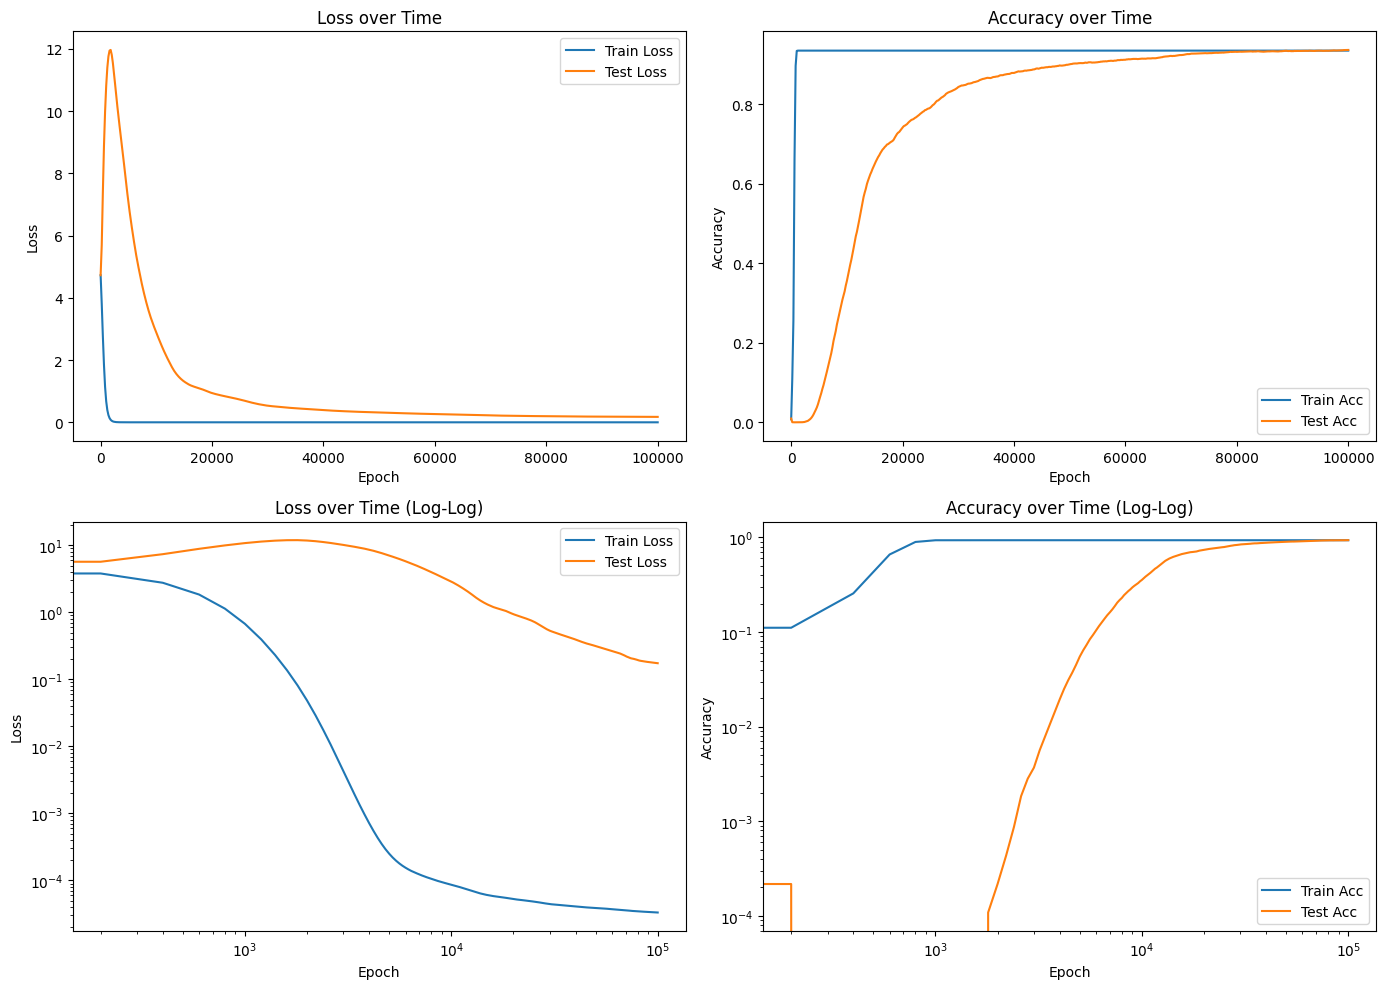

In [9]:
result = train_and_test_with_params(seed=42)
graphic(*result)